In [1]:
import gdown

file_id = "1WEySXMFz6v1OgPkLKJ8QIp3Lk-eyTObY"
url = f"https://drive.google.com/uc?id={file_id}"

output = "/kaggle/working/teeth_dataset.zip"
gdown.download(url, output, quiet=False)

import zipfile

with zipfile.ZipFile("/kaggle/working/teeth_dataset.zip", 'r') as zip_ref:
    zip_ref.extractall("/kaggle/working/teeth_dataset")

import os

BASE_PATH = "/kaggle/working/teeth_dataset/Teeth_Dataset"

TRAIN_DIR = os.path.join(BASE_PATH, "Training")
VAL_DIR   = os.path.join(BASE_PATH, "Validation")
TEST_DIR  = os.path.join(BASE_PATH, "Testing")

print("Train path:", TRAIN_DIR)
print("Val path:", VAL_DIR)
print("Test path:", TEST_DIR)

Downloading...
From (original): https://drive.google.com/uc?id=1WEySXMFz6v1OgPkLKJ8QIp3Lk-eyTObY
From (redirected): https://drive.google.com/uc?id=1WEySXMFz6v1OgPkLKJ8QIp3Lk-eyTObY&confirm=t&uuid=baf35f5b-fe0a-45d4-b31b-6390c7ff422c
To: /kaggle/working/teeth_dataset.zip
100%|██████████| 49.1M/49.1M [00:01<00:00, 42.4MB/s]


Train path: /kaggle/working/teeth_dataset/Teeth_Dataset/Training
Val path: /kaggle/working/teeth_dataset/Teeth_Dataset/Validation
Test path: /kaggle/working/teeth_dataset/Teeth_Dataset/Testing


In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

import random
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from sklearn.metrics import confusion_matrix,classification_report

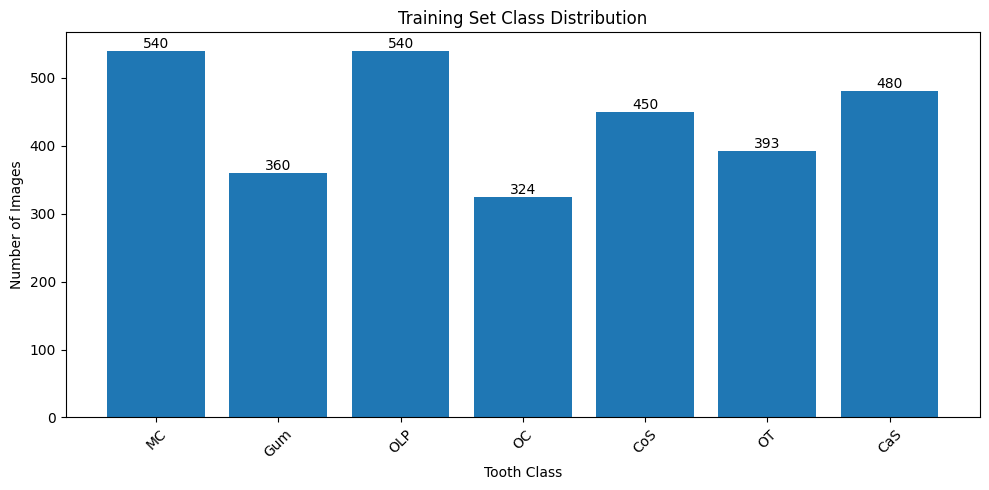

In [3]:
classes = os.listdir(TRAIN_DIR)
num_classes = len(classes)

class_counts = []
for cls in classes:
    count = len(os.listdir(os.path.join(TRAIN_DIR, cls)))
    class_counts.append(count)

plt.figure(figsize=(10, 5))
bars = plt.bar(classes, class_counts)

plt.title('Training Set Class Distribution')
plt.xlabel('Tooth Class')
plt.ylabel('Number of Images')
plt.xticks(rotation=45)

for bar in bars:
    yvalue = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yvalue, int(yvalue), ha='center', va='bottom')

plt.tight_layout()
plt.savefig("/kaggle/working/training_class_distribution.png")
plt.show()

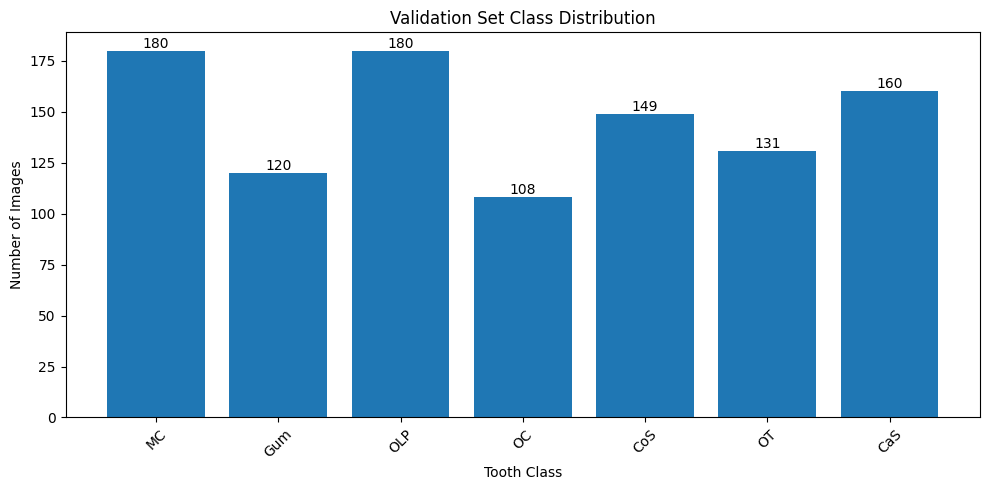

In [7]:
classes = os.listdir(VAL_DIR)
num_classes = len(classes)

class_counts = []
for cls in classes:
    count = len(os.listdir(os.path.join(VAL_DIR, cls)))
    class_counts.append(count)

plt.figure(figsize=(10, 5))
bars = plt.bar(classes, class_counts)

plt.title('Validation Set Class Distribution')
plt.xlabel('Tooth Class')
plt.ylabel('Number of Images')
plt.xticks(rotation=45)

for bar in bars:
    yvalue = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yvalue, int(yvalue), ha='center', va='bottom')

plt.tight_layout()
plt.savefig("/kaggle/working/val_class_distribution.png")
plt.show()

In [5]:
import shutil

valid_classes = ['CaS', 'CoS', 'Gum', 'MC', 'OC', 'OLP', 'OT']

for item in os.listdir(TEST_DIR):
    item_path = os.path.join(TEST_DIR, item)
    
    if item not in valid_classes:
        try:
            if os.path.isdir(item_path):
                shutil.rmtree(item_path) # delete folder
                print(f"Unnecessary Item Deleted: {item}")
            else:
                os.remove(item_path) # delete file
                print(f"Unnecessary File Deleted: {item}")
        except Exception as e:
            print(f"Error Existing {item}: {e}")

print("Testing Class is clean now")

Unnecessary Item Deleted: out
Unnecessary File Deleted: output_image.jpg
Unnecessary Item Deleted: outputs
Unnecessary Item Deleted: output
Testing Class is clean now


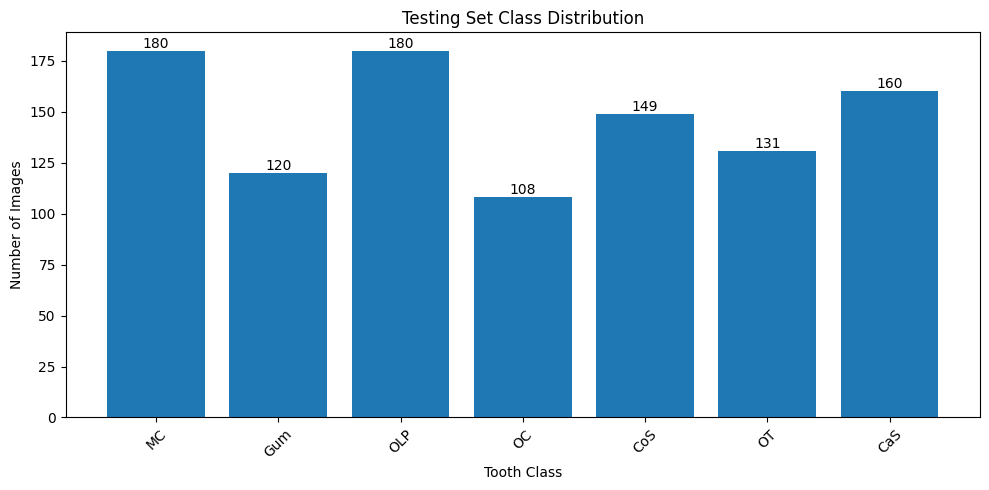

In [8]:
classes = os.listdir(TEST_DIR)
num_classes = len(classes)

class_counts = []
for cls in classes:
    count = len(os.listdir(os.path.join(TEST_DIR, cls)))
    class_counts.append(count)

plt.figure(figsize=(10, 5))
bars = plt.bar(classes, class_counts)

plt.title('Testing Set Class Distribution')
plt.xlabel('Tooth Class')
plt.ylabel('Number of Images')
plt.xticks(rotation=45)

for bar in bars:
    yvalue = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yvalue, int(yvalue), ha='center', va='bottom')

plt.tight_layout()
plt.savefig("/kaggle/working/test_class_distribution.png")
plt.show()

In [9]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

In [12]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

In [13]:
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=SEED
)

val_generator = train_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 3087 images belonging to 7 classes.
Found 1028 images belonging to 7 classes.


In [21]:
test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 1028 images belonging to 7 classes.


In [14]:
base_model = EfficientNetB0(
    include_top=False,
    weights='imagenet',
    input_shape=(224, 224, 3)
)

base_model.trainable = False

I0000 00:00:1770728476.583585      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [15]:
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(num_classes, activation='softmax')
])

In [16]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [17]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,384,426 (16.73 MB)

 Trainable params: 332,295 (1.27 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

In [18]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=4, min_lr=1e-6, verbose=1)
]

In [20]:
history = model.fit(train_generator, validation_data=val_generator, epochs=50, callbacks=callbacks)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
I0000 00:00:1770728907.979435     754 service.cc:152] XLA service 0x78668c114de0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1770728907.979479     754 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1770728910.129303     754 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1770728920.799358     754 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


97/97 ━━━━━━━━━━━━━━━━━━━━ 50s 284ms/step - accuracy: 0.5537 - loss: 1.4452 - val_accuracy: 0.8181 - val_loss: 0.6601 - learning_rate: 0.0010
Epoch 2/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step - accuracy: 0.8709 - loss: 0.3783 - val_accuracy: 0.9183 - val_loss: 0.3142 - learning_rate: 0.0010
Epoch 3/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - accuracy: 0.9284 - loss: 0.2137 - val_accuracy: 0.9572 - val_loss: 0.1510 - learning_rate: 0.0010
Epoch 4/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - accuracy: 0.9422 - loss: 0.1609 - val_accuracy: 0.9660 - val_loss: 0.1091 - learning_rate: 0.0010
Epoch 5/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - accuracy: 0.9712 - loss: 0.0874 - val_accuracy: 0.9698 - val_loss: 0.0893 - learning_rate: 0.0010
Epoch 6/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - accuracy: 0.9716 - loss: 0.0859 - val_accuracy: 0.9757 - val_loss: 0.0806 - learning_rate: 0.0010
Epoch 7/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - accuracy: 0.9789 - loss: 0.0747 - val_accuracy: 0.

In [23]:
test_loss, test_acc = model.evaluate(test_generator)
print("Test Accuracy:", test_acc)

33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.9952 - loss: 0.0184
Test Accuracy: 0.9912451505661011


In [25]:
results = pd.DataFrame({
    'Model': ['EfficientNet'],
    'Best Acc': [
        max(history.history['accuracy']),
    ],
    'Best Val Acc': [
        max(history.history['val_accuracy']),
    ],
    'Best Val Loss': [
        min(history.history['val_loss']),
    ],
    'Final Val Acc': [
        history.history['val_accuracy'][-1],
    ],
    'Final Acc': [
        history.history['accuracy'][-1],
    ],
    'Final Val Loss': [
        history.history['val_loss'][-1],
    ]
})
results.head()

,Model,Best Acc,Best Val Acc,Best Val Loss,Final Val Acc,Final Acc,Final Val Loss
0,EfficientNet,0.996761,0.996109,0.025242,0.993191,0.996113,0.027621


In [27]:
def plot_training_history(history, model_name):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(14, 5))

    # Accuracy plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, label='Training Accuracy')
    plt.plot(epochs, val_acc, label='Validation Accuracy')
    plt.title(f'{model_name} - Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    # Loss plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, label='Training Loss')
    plt.plot(epochs, val_loss, label='Validation Loss')
    plt.title(f'{model_name} - Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.savefig("/kaggle/working/efficientnet_model_result.png")
    plt.show()

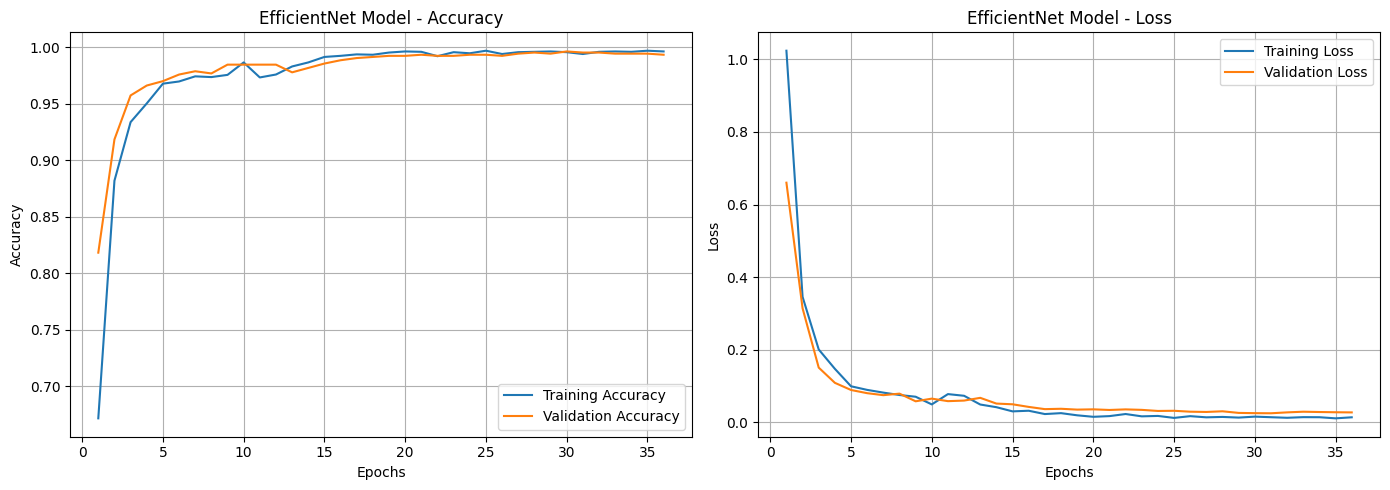

In [28]:
plot_training_history(history, "EfficientNet Model")

33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step


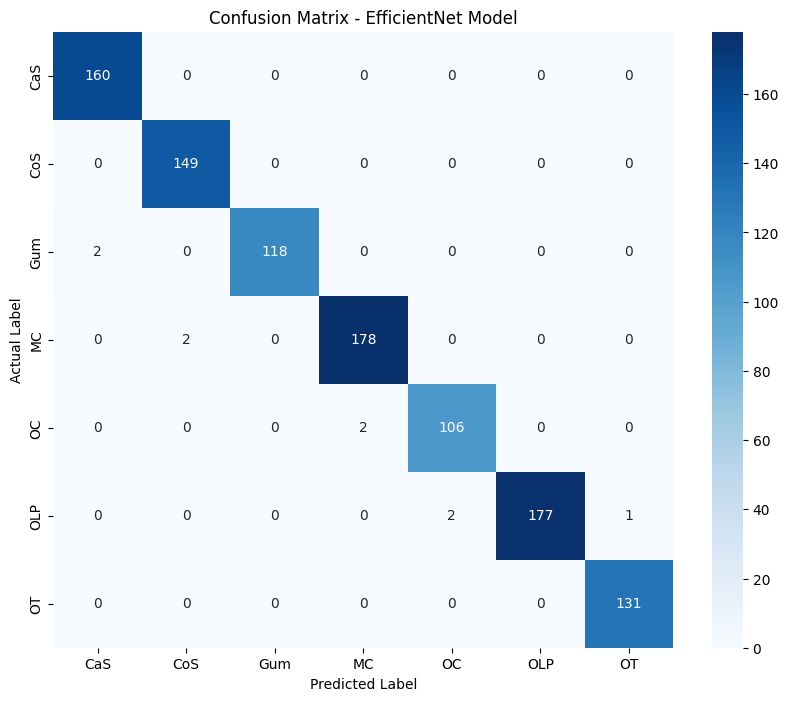


Classification Report:

              precision    recall  f1-score   support

         CaS       0.99      1.00      0.99       160
         CoS       0.99      1.00      0.99       149
         Gum       1.00      0.98      0.99       120
          MC       0.99      0.99      0.99       180
          OC       0.98      0.98      0.98       108
         OLP       1.00      0.98      0.99       180
          OT       0.99      1.00      1.00       131

    accuracy                           0.99      1028
   macro avg       0.99      0.99      0.99      1028
weighted avg       0.99      0.99      0.99      1028



In [32]:
y_pred_probs = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred_probs, axis=1)

y_true = test_generator.classes

# Confusion Matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_true, y_pred_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=valid_classes, yticklabels=valid_classes)

plt.title('Confusion Matrix - EfficientNet Model')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.savefig("/kaggle/working/EfficientNet_confusion_matrix.png")
plt.show()

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred_classes, target_names=valid_classes))

In [33]:
model.save("EfficientNet_classification_model.h5")

print("EfficientNet Model Saved")

EfficientNet Model Saved
